# FOLD-TOMO-03B: Recovering Address from Fold Shape — Companion Notebook

**Paper support:** *The Algebraic Inversion of Discrete Computational Folds*  
**Notebook ID:** `FOLD-TOMO-03B`  
**Addendum ID:** `FOLD-TOMO-03A`  
**Branch:** Nexus Fold Tomography  

This notebook reproduces the formula/data locks for the paper and addendum:

$$\boxed{\text{Forward collapse hides address; reverse recovery restores address by reading shape.}}$$

Core executable collapse:

$$\boxed{2048\rightarrow1600\rightarrow448}$$


In [1]:
# Cell 1 — setup
import sys, subprocess, importlib.util, math, random, time
from collections import defaultdict
required=["numpy","matplotlib","mpmath"]
missing=[p for p in required if importlib.util.find_spec(p) is None]
if missing:
    subprocess.check_call([sys.executable,"-m","pip","install","-q",*missing])
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
plt.rcParams["figure.figsize"]=(12,5)
plt.rcParams["axes.grid"]=True
RUN_FULL_RANK=True
RUN_VISUALS=True
print("Environment ready.")


Environment ready.


In [2]:
# Cell 2 — seed

def pi_fractional_digits(n=2048, guard=50):
    mp.mp.dps=n+guard
    return str(mp.pi).split(".")[1][:n]

N=2048
digits=pi_fractional_digits(N)
decimal_seed=[int(c) for c in digits]
parity_seed=[d & 1 for d in decimal_seed]
print("N:",N)
print("first 32 fractional digits:",digits[:32])
print("Decimal S0:",sum(decimal_seed))
print("Parity S0:",sum(parity_seed))
assert len(digits)==2048
assert digits[:20]=="14159265358979323846"
assert sum(decimal_seed)==9338
assert sum(parity_seed)==1034


N: 2048
first 32 fractional digits: 14159265358979323846264338327950
Decimal S0: 9338
Parity S0: 1034


In [3]:
# Cell 3 — folds

def decimal_difference_rows(seed):
    rows=[list(seed)]
    cur=list(seed)
    while len(cur)>1:
        cur=[abs(b-a) for a,b in zip(cur,cur[1:])]
        rows.append(cur)
    return rows

def xor_rows(seed_bits):
    rows=[list(seed_bits)]
    cur=list(seed_bits)
    while len(cur)>1:
        cur=[a^b for a,b in zip(cur,cur[1:])]
        rows.append(cur)
    return rows

t0=time.time()
decimal_rows=decimal_difference_rows(decimal_seed)
xor_lattice=xor_rows(parity_seed)
print(f"Built rows in {time.time()-t0:.3f}s")
assert len(decimal_rows)==N and len(xor_lattice)==N
assert len(decimal_rows[-1])==1 and len(xor_lattice[-1])==1


Built rows in 0.142s


In [4]:
# Cell 4 — exact parity shadow
bad=None
for level in range(N):
    if [(v & 1) for v in decimal_rows[level]] != xor_lattice[level]:
        bad=level
        break
print("Parity shadow exact:", bad is None)
assert bad is None


Parity shadow exact: True


## Lucas Sampling Law

$$x^{(\ell)}=(I+E)^\ell x^{(0)}$$

$$x_i^{(\ell)}=\bigoplus_{j\subseteq\ell}x_{i+j}^{(0)}$$


In [5]:
# Cell 5 — Lucas masks

def popcount(n): return bin(int(n)).count("1")

def lucas_offsets(level):
    level=int(level); offsets=[0]; bit=1; n=level
    while n:
        if n & 1:
            offsets = offsets + [o+bit for o in offsets]
        n >>= 1; bit <<= 1
    return offsets

def row_from_lucas(seed_bits, level):
    offsets=lucas_offsets(level)
    out=[]
    for i in range(len(seed_bits)-level):
        v=0
        for j in offsets: v ^= seed_bits[i+j]
        out.append(v)
    return out

test_levels=[0,1,2,3,13,110,300,342,376,448,496,512,556,640,688,1024,2032,2040,2044,2046,2047]
for level in test_levels:
    assert len(lucas_offsets(level)) == 2**popcount(level)
    assert row_from_lucas(parity_seed, level) == xor_lattice[level]
for level in [110,448,512,640,2040,2044,2046,2047]:
    off=lucas_offsets(level)
    print(f"level={level:4d}, binary={level:b}, popcount={popcount(level):2d}, mask_size={len(off):4d}")
    print(" offsets:", off[:16], "..." if len(off)>16 else "")
assert lucas_offsets(448)==[0,64,128,192,256,320,384,448]
assert lucas_offsets(512)==[0,512]


level= 110, binary=1101110, popcount= 5, mask_size=  32
 offsets: [0, 2, 4, 6, 8, 10, 12, 14, 32, 34, 36, 38, 40, 42, 44, 46] ...
level= 448, binary=111000000, popcount= 3, mask_size=   8
 offsets: [0, 64, 128, 192, 256, 320, 384, 448] 
level= 512, binary=1000000000, popcount= 1, mask_size=   2
 offsets: [0, 512] 
level= 640, binary=1010000000, popcount= 2, mask_size=   4
 offsets: [0, 128, 512, 640] 
level=2040, binary=11111111000, popcount= 8, mask_size= 256
 offsets: [0, 8, 16, 24, 32, 40, 48, 56, 64, 72, 80, 88, 96, 104, 112, 120] ...
level=2044, binary=11111111100, popcount= 9, mask_size= 512
 offsets: [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60] ...
level=2046, binary=11111111110, popcount=10, mask_size=1024
 offsets: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30] ...
level=2047, binary=11111111111, popcount=11, mask_size=2048
 offsets: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] ...


In [6]:
# Cell 6 — metrics

def trace_metrics(rows):
    N_vals=np.array([len(r) for r in rows], dtype=int)
    S_vals=np.array([sum(r) for r in rows], dtype=int)
    rho=S_vals/N_vals
    R=S_vals-N_vals/2.0
    eps=2*R/N_vals
    return {"N":N_vals,"S":S_vals,"rho":rho,"R":R,"eps":eps,
            "p_plus":(1+eps)/2,"p_minus":(1-eps)/2,
            "dS":np.diff(S_vals),"dR":np.diff(R),
            "locks":[i for i,v in enumerate(R) if v==0]}

binary_trace=trace_metrics(xor_lattice)
decimal_N=np.array([len(r) for r in decimal_rows], dtype=int)
decimal_S=np.array([sum(r) for r in decimal_rows], dtype=int)
amp_collapse_13=(decimal_S[0]-decimal_S[13])/decimal_S[0]
expected_amp=(9338-1092)/9338
print("Decimal S0:", decimal_S[0])
print("Decimal S13:", decimal_S[13])
print("Amplitude collapse:", amp_collapse_13)
print("Binary N0:", binary_trace["N"][0])
print("Binary S0:", binary_trace["S"][0])
print("Binary R0:", binary_trace["R"][0])
assert decimal_S[0]==9338 and decimal_S[13]==1092
assert abs(amp_collapse_13-expected_amp) < 1e-15
assert binary_trace["S"][0]==1034 and binary_trace["R"][0]==10.0


Decimal S0: 9338
Decimal S13: 1092
Amplitude collapse: 0.8830584707646177
Binary N0: 2048
Binary S0: 1034
Binary R0: 10.0


In [7]:
# Cell 7 — structural locks

def summarize_level(level):
    row=xor_lattice[level]; n=len(row); s=sum(row); r=s-n/2
    print(f"ℓ={level:4d}: N={n:4d}, S={s:4d}, rho={s/n:.12f}, R={r}")
    if n<=32: print(" row:", row)
for level in [448,512,2032,2040,2044,2046,2047]: summarize_level(level)
assert binary_trace["N"][448]==1600 and binary_trace["S"][448]==800 and binary_trace["R"][448]==0.0
assert binary_trace["N"][512]==1536 and binary_trace["S"][512]==764 and binary_trace["R"][512]==-4.0
assert xor_lattice[2046]==[1,1] and xor_lattice[2047]==[0]


ℓ= 448: N=1600, S= 800, rho=0.500000000000, R=0.0
ℓ= 512: N=1536, S= 764, rho=0.497395833333, R=-4.0
ℓ=2032: N=  16, S=   8, rho=0.500000000000, R=0.0
 row: [0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1]
ℓ=2040: N=   8, S=   4, rho=0.500000000000, R=0.0
 row: [1, 0, 0, 1, 0, 1, 0, 1]
ℓ=2044: N=   4, S=   2, rho=0.500000000000, R=0.0
 row: [1, 1, 0, 0]
ℓ=2046: N=   2, S=   2, rho=1.000000000000, R=1.0
 row: [1, 1]
ℓ=2047: N=   1, S=   0, rho=0.000000000000, R=-0.5
 row: [0]


In [8]:
# Cell 8 — residue counts
zero_R_levels=binary_trace["locks"]
nonzero_R_levels=[i for i,R in enumerate(binary_trace["R"]) if R!=0]
print("Total levels:", len(binary_trace["R"]))
print("R=0:", len(zero_R_levels))
print("R!=0:", len(nonzero_R_levels))
print("Check:", len(zero_R_levels)+len(nonzero_R_levels))
print("First 15 locks:", zero_R_levels[:15])
print("Last 20 locks:", zero_R_levels[-20:])
interior_start=20; interior_end=1800
interior_R=binary_trace["R"][interior_start:interior_end]
interior_zero=[interior_start+i for i,r in enumerate(interior_R) if r==0]
interior_nonzero=[interior_start+i for i,r in enumerate(interior_R) if r!=0]
print(f"Interior window: {interior_start} <= ℓ < {interior_end}")
print("Interior length:", len(interior_R))
print("Interior R=0:", len(interior_zero))
print("Interior R!=0:", len(interior_nonzero))
assert len(zero_R_levels)==44 and len(nonzero_R_levels)==2004
assert len(interior_R)==1780 and len(interior_zero)==30 and len(interior_nonzero)==1750
assert zero_R_levels[:15] == [110,300,342,376,448,496,556,640,688,854,898,932,954,1076,1260]


Total levels: 2048
R=0: 44
R!=0: 2004
Check: 2048
First 15 locks: [110, 300, 342, 376, 448, 496, 556, 640, 688, 854, 898, 932, 954, 1076, 1260]
Last 20 locks: [1670, 1744, 1754, 1772, 1776, 1786, 1830, 1850, 1942, 1944, 1968, 1970, 1990, 1998, 2002, 2022, 2030, 2032, 2040, 2044]
Interior window: 20 <= ℓ < 1800
Interior length: 1780
Interior R=0: 30
Interior R!=0: 1750


In [9]:
# Cell 9 — dyadic terminal theorem

def dyadic_terminal_row_from_seed(seed_bits,k):
    n=len(seed_bits); modulus=1<<k; out=[]
    for i in range(modulus):
        v=0
        for q in range(i,n,modulus): v ^= seed_bits[q]
        out.append(v)
    return out
m=int(math.log2(N)); assert 2**m==N
dyadic_summary=[]
for k in range(m):
    level=N-(1<<k)
    theorem_row=dyadic_terminal_row_from_seed(parity_seed,k)
    lattice_row=xor_lattice[level]
    ok=theorem_row==lattice_row
    dyadic_summary.append((k,level,len(lattice_row),ok))
    assert ok
for k,level,row_len,ok in dyadic_summary:
    print(f"k={k:2d}, level={level:4d}, row_len={row_len:4d}, theorem_match={ok}")
    if k<=4: print(" row:", xor_lattice[level])


k= 0, level=2047, row_len=   1, theorem_match=True
 row: [0]
k= 1, level=2046, row_len=   2, theorem_match=True
 row: [1, 1]
k= 2, level=2044, row_len=   4, theorem_match=True
 row: [1, 1, 0, 0]
k= 3, level=2040, row_len=   8, theorem_match=True
 row: [1, 0, 0, 1, 0, 1, 0, 1]
k= 4, level=2032, row_len=  16, theorem_match=True
 row: [0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1]
k= 5, level=2016, row_len=  32, theorem_match=True
k= 6, level=1984, row_len=  64, theorem_match=True
k= 7, level=1920, row_len= 128, theorem_match=True
k= 8, level=1792, row_len= 256, theorem_match=True
k= 9, level=1536, row_len= 512, theorem_match=True
k=10, level=1024, row_len=1024, theorem_match=True


In [10]:
# Cell 10 — GF(2) rank engine

def masks_for_level(n, level):
    offsets=lucas_offsets(level); masks=[]
    for i in range(n-level):
        mask=0
        for j in offsets: mask |= 1 << (i+j)
        masks.append(mask)
    return masks

def gf2_rank_int(rows):
    basis={}
    for row in rows:
        x=int(row)
        while x:
            pivot=x.bit_length()-1
            if pivot in basis: x ^= basis[pivot]
            else:
                basis[pivot]=x; break
    return len(basis)
print("Rank engine ready.")


Rank engine ready.


In [11]:
# Cell 11 — full rank verification
if RUN_FULL_RANK:
    t0=time.time()
    dyadic_masks=[]
    for k in range(m):
        dyadic_masks.extend(masks_for_level(N, N-(1<<k)))
    masks_448=masks_for_level(N,448); masks_512=masks_for_level(N,512)
    rank_dyadic=gf2_rank_int(dyadic_masks)
    rank_448=gf2_rank_int(masks_448)
    rank_512=gf2_rank_int(masks_512)
    rank_dyadic_448=gf2_rank_int(dyadic_masks+masks_448)
    rank_dyadic_512=gf2_rank_int(dyadic_masks+masks_512)
    rank_all=gf2_rank_int(dyadic_masks+masks_448+masks_512)
    print(f"Rank time: {time.time()-t0:.3f}s")
    print("Dyadic equation count:", len(dyadic_masks))
    print("rank(dyadic):", rank_dyadic)
    print("rank(448):", rank_448)
    print("rank(512):", rank_512)
    print("rank(dyadic+448):", rank_dyadic_448)
    print("rank(dyadic+512):", rank_dyadic_512)
    print("rank(all):", rank_all)
    print("remaining degrees:", N-rank_dyadic_448)
    assert len(dyadic_masks)==2047
    assert rank_dyadic==1024 and rank_448==1600 and rank_512==1536
    assert rank_dyadic_448==1600 and rank_dyadic_512==1536 and rank_all==1600
    assert N-rank_dyadic_448==448


Rank time: 0.009s
Dyadic equation count: 2047
rank(dyadic): 1024
rank(448): 1600
rank(512): 1536
rank(dyadic+448): 1600
rank(dyadic+512): 1536
rank(all): 1600
remaining degrees: 448


In [12]:
# Cell 12 — shift-XOR reverse demo

def reverse_one_shift_xor(y, shift, boundary):
    assert len(boundary)==shift
    x=list(boundary)+[0]*len(y)
    for i,yi in enumerate(y): x[i+shift]=x[i]^yi
    return x
x_true=[1,0,1,1,0,0,1,0,1,1]
shift=3
y=[x_true[i]^x_true[i+shift] for i in range(len(x_true)-shift)]
x_rec=reverse_one_shift_xor(y,shift,x_true[:shift])
print("x_true:", x_true); print("y:", y); print("x_rec:", x_rec)
assert x_rec==x_true


x_true: [1, 0, 1, 1, 0, 0, 1, 0, 1, 1]
y: [0, 0, 1, 0, 0, 1, 0]
x_rec: [1, 0, 1, 1, 0, 0, 1, 0, 1, 1]


In [13]:
# Cell 13 — complement symmetry
rng=random.Random(20260505)
demo_bits=[rng.randrange(2) for _ in range(64)]
demo_comp=[b^1 for b in demo_bits]
for level in [1,2,3,5,7,8,13,31]:
    assert row_from_lucas(demo_bits,level)==row_from_lucas(demo_comp,level)
print("Positive-depth parity rows are invariant under global complement.")


Positive-depth parity rows are invariant under global complement.


In [14]:
# Cell 14 — small-N decoder demo

def int_to_bits(n,width): return [(n>>i)&1 for i in range(width)]
def bits_to_int(bits):
    out=0
    for i,b in enumerate(bits):
        if b: out |= 1<<i
    return out
def dyadic_levels_for_N(n):
    mm=int(math.log2(n)); assert 2**mm==n
    return [n-(1<<k) for k in range(mm)]
def linear_signature(bits,levels): return tuple(tuple(row_from_lucas(bits,l)) for l in levels)
def weight_signature(bits): return tuple(sum(r) for r in xor_rows(bits))
N_demo=16
seed_demo=parity_seed[:N_demo]
seed_demo_int=bits_to_int(seed_demo)
linear_levels_demo=dyadic_levels_for_N(N_demo)+[7]
target_linear=linear_signature(seed_demo,linear_levels_demo)
target_weight=weight_signature(seed_demo)
linear_candidates=[]; weight_candidates=[]
for n in range(1<<N_demo):
    bits=int_to_bits(n,N_demo)
    if linear_signature(bits,linear_levels_demo)==target_linear:
        linear_candidates.append(n)
        if weight_signature(bits)==target_weight: weight_candidates.append(n)
print("Seed demo bits:", seed_demo)
print("Seed demo int:", seed_demo_int)
print("Linear levels:", linear_levels_demo)
print("Linear candidates:", len(linear_candidates))
print("Weight-trace candidates:", len(weight_candidates), weight_candidates)
assert seed_demo_int in linear_candidates and seed_demo_int in weight_candidates
assert len(weight_candidates)==1 and weight_candidates[0]==seed_demo_int


Seed demo bits: [1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0]
Seed demo int: 31645
Linear levels: [15, 14, 12, 8, 7]
Linear candidates: 128
Weight-trace candidates: 1 [31645]


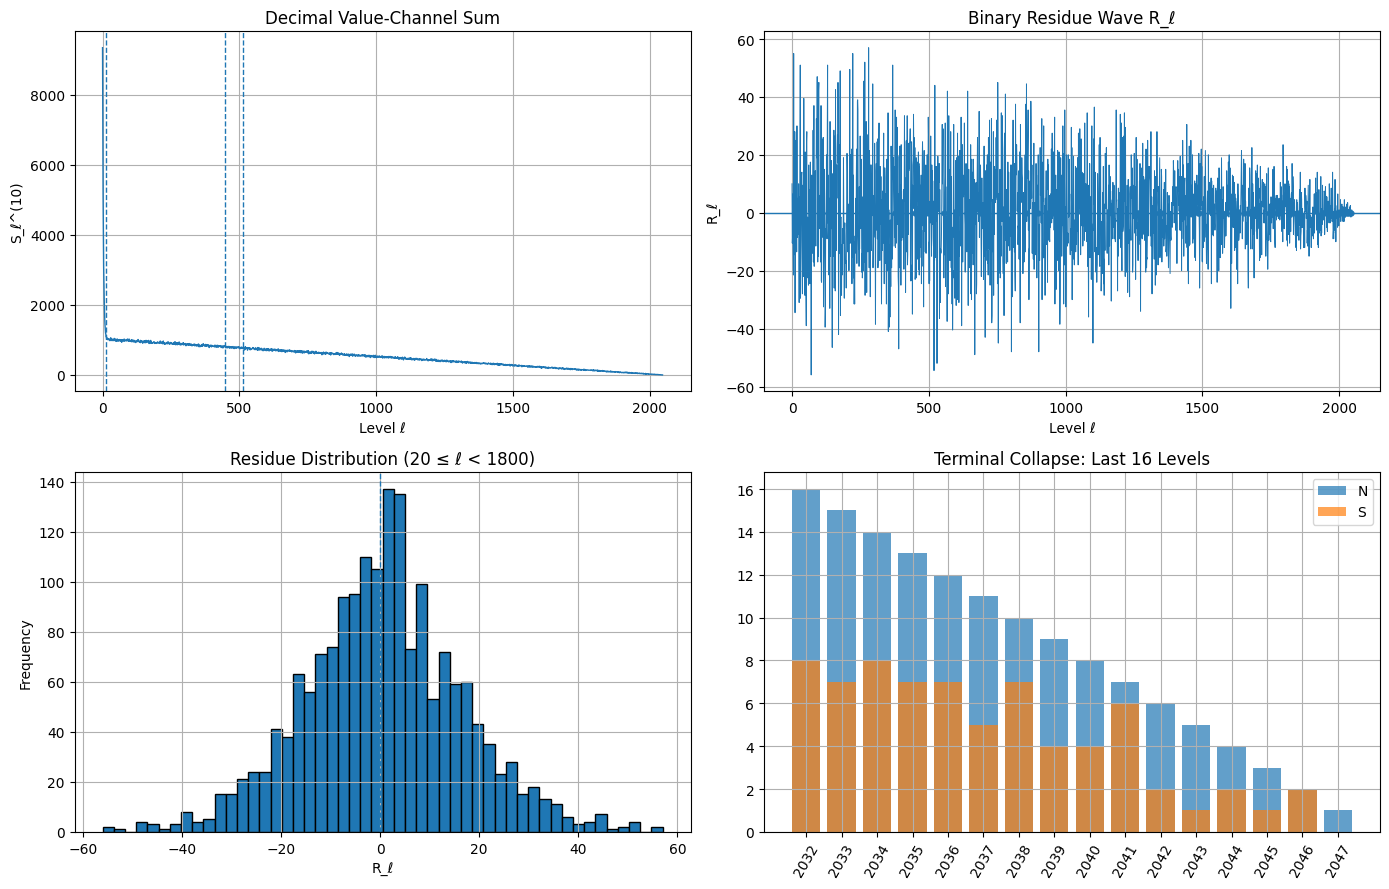

In [15]:
# Cell 15 — visual diagnostics
if RUN_VISUALS:
    fig,axes=plt.subplots(2,2,figsize=(14,9))
    axes[0,0].plot(decimal_S, linewidth=1)
    for level in [13,448,512]: axes[0,0].axvline(level, linestyle="--", linewidth=1)
    axes[0,0].set_title("Decimal Value-Channel Sum"); axes[0,0].set_xlabel("Level ℓ"); axes[0,0].set_ylabel("S_ℓ^(10)")
    R=binary_trace["R"]
    axes[0,1].plot(R, linewidth=.7); axes[0,1].scatter(binary_trace["locks"],[0]*len(binary_trace["locks"]),s=12); axes[0,1].axhline(0, linewidth=1)
    axes[0,1].set_title("Binary Residue Wave R_ℓ"); axes[0,1].set_xlabel("Level ℓ"); axes[0,1].set_ylabel("R_ℓ")
    segment=R[20:1800]
    axes[1,0].hist(segment,bins=50,edgecolor="black"); axes[1,0].axvline(0, linestyle="--", linewidth=1)
    axes[1,0].set_title("Residue Distribution (20 ≤ ℓ < 1800)"); axes[1,0].set_xlabel("R_ℓ"); axes[1,0].set_ylabel("Frequency")
    last=list(range(2032,2048))
    axes[1,1].bar([str(l) for l in last],binary_trace["N"][last],alpha=.7,label="N")
    axes[1,1].bar([str(l) for l in last],binary_trace["S"][last],alpha=.7,label="S")
    axes[1,1].set_title("Terminal Collapse: Last 16 Levels"); axes[1,1].tick_params(axis="x",rotation=60); axes[1,1].legend()
    plt.tight_layout(); plt.show()


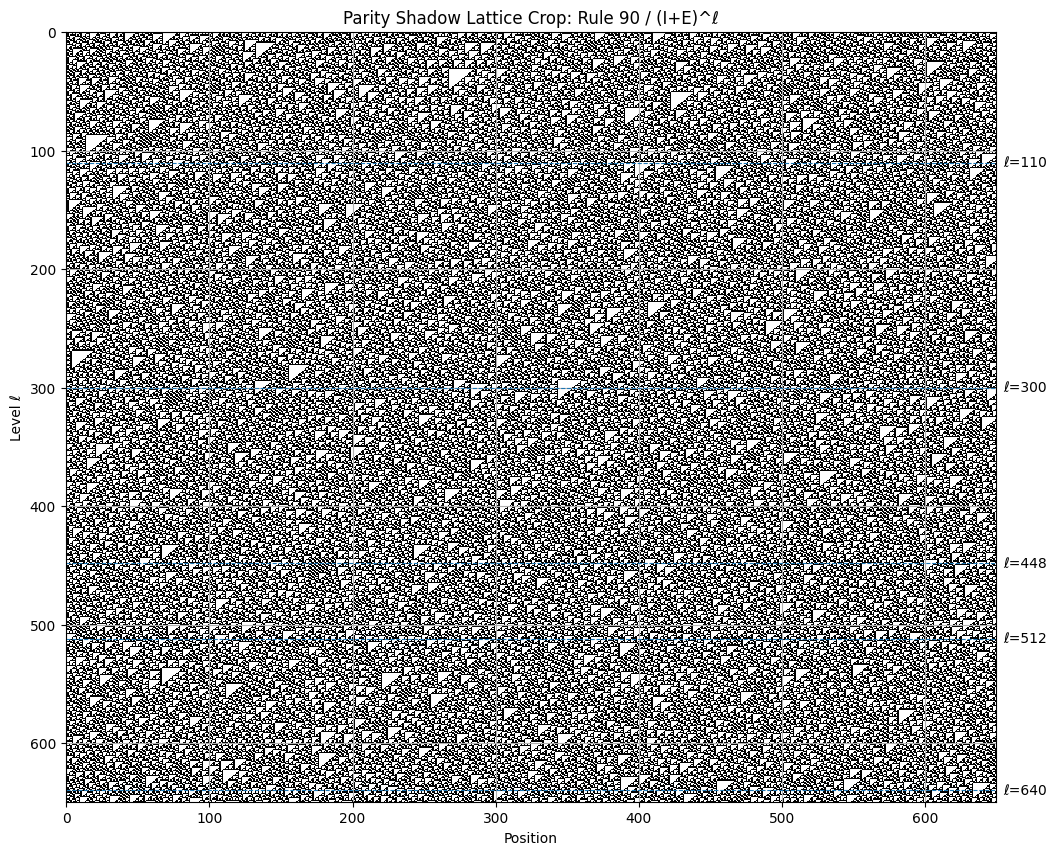

In [16]:
# Cell 16 — parity lattice crop
if RUN_VISUALS:
    max_levels=650; max_cols=650
    img=np.ones((max_levels,max_cols), dtype=float)
    for level in range(max_levels):
        for i,bit in enumerate(xor_lattice[level][:max_cols]): img[level,i]=0.0 if bit else 1.0
    plt.figure(figsize=(12,10)); plt.imshow(img,cmap="gray",aspect="auto",interpolation="nearest")
    for level in [110,300,448,512,640]:
        plt.axhline(level, linestyle="--", linewidth=.8); plt.text(max_cols+5, level, f"ℓ={level}", va="center")
    plt.title("Parity Shadow Lattice Crop: Rule 90 / (I+E)^ℓ"); plt.xlabel("Position"); plt.ylabel("Level ℓ"); plt.show()


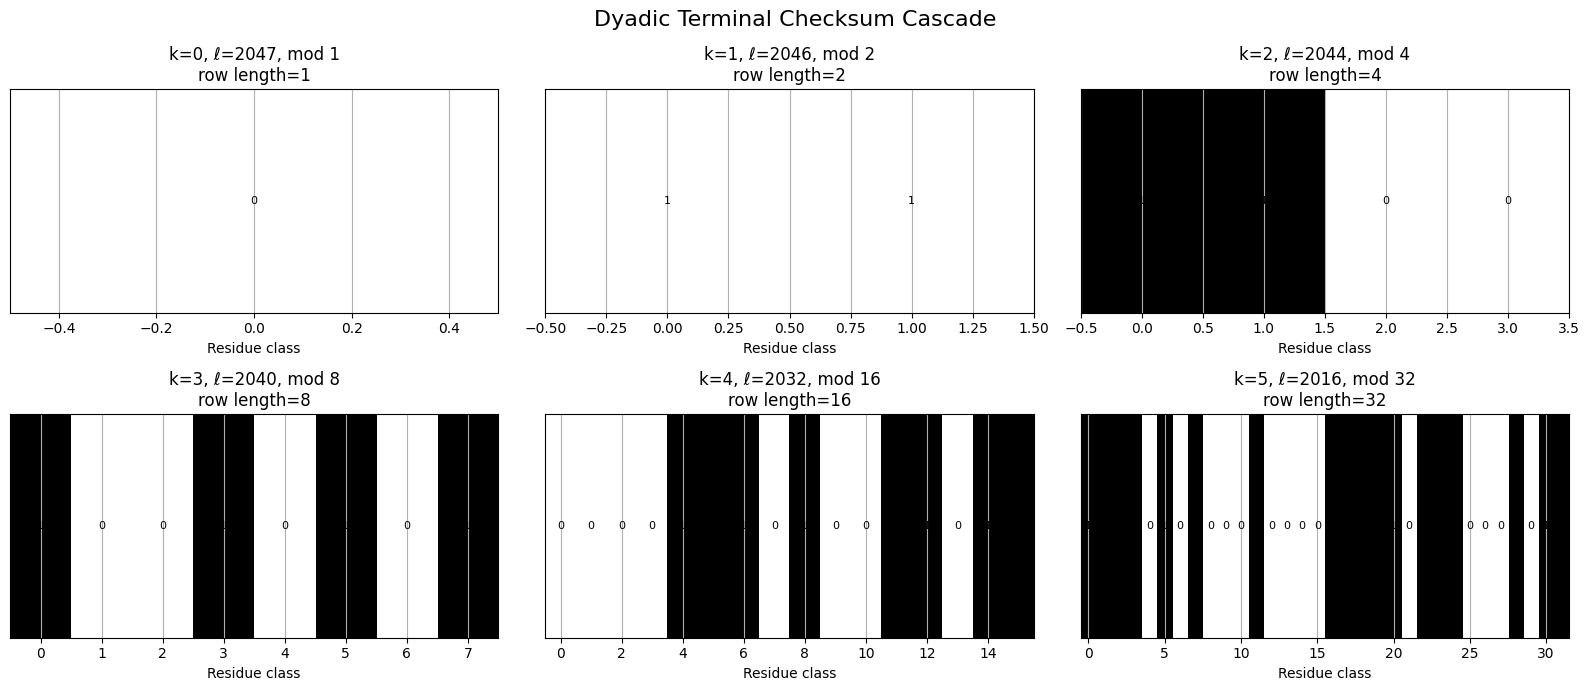

In [17]:
# Cell 17 — dyadic terminal cascade visualization
if RUN_VISUALS:
    fig,axes=plt.subplots(2,3,figsize=(16,7)); axes=axes.ravel()
    for idx,k in enumerate(range(6)):
        level=N-(1<<k); row=xor_lattice[level]; ax=axes[idx]
        ax.imshow(np.array([row]), cmap="gray_r", aspect="auto", interpolation="nearest")
        ax.set_title(f"k={k}, ℓ={level}, mod {1<<k}\nrow length={len(row)}")
        ax.set_yticks([]); ax.set_xlabel("Residue class")
        for i,bit in enumerate(row): ax.text(i,0,str(bit),ha="center",va="center",fontsize=8)
    plt.suptitle("Dyadic Terminal Checksum Cascade", fontsize=16); plt.tight_layout(); plt.show()


In [18]:
# Cell 18 — final validation
checks={
 "decimal_S0": int(decimal_S[0])==9338,
 "decimal_S13": int(decimal_S[13])==1092,
 "parity_shadow_exact": bad is None,
 "level_448_lock": int(binary_trace["N"][448])==1600 and int(binary_trace["S"][448])==800 and float(binary_trace["R"][448])==0.0,
 "level_512_lock": int(binary_trace["N"][512])==1536 and int(binary_trace["S"][512])==764 and float(binary_trace["R"][512])==-4.0,
 "terminal_gate": xor_lattice[2046]==[1,1] and xor_lattice[2047]==[0],
 "full_R_counts": len(zero_R_levels)==44 and len(nonzero_R_levels)==2004,
 "interior_R_counts": len(interior_zero)==30 and len(interior_nonzero)==1750,
 "dyadic_theorem": all(ok for _,_,_,ok in dyadic_summary),
}
if RUN_FULL_RANK:
    checks.update({
      "rank_dyadic": rank_dyadic==1024,
      "rank_448": rank_448==1600,
      "rank_512": rank_512==1536,
      "rank_dyadic_448": rank_dyadic_448==1600,
      "nullity_after_dyadic_448": (N-rank_dyadic_448)==448,
    })
print("FINAL VALIDATION")
print("="*80)
for name,ok in checks.items(): print(f"{name:30s}: {ok}")
assert all(checks.values())
print("\nFOLD-TOMO-03B validation complete.")
print("Core executable collapse: 2048 -> 1600 -> 448")


FINAL VALIDATION
decimal_S0                    : True
decimal_S13                   : True
parity_shadow_exact           : True
level_448_lock                : True
level_512_lock                : True
terminal_gate                 : True
full_R_counts                 : True
interior_R_counts             : True
dyadic_theorem                : True
rank_dyadic                   : True
rank_448                      : True
rank_512                      : True
rank_dyadic_448               : True
nullity_after_dyadic_448      : True

FOLD-TOMO-03B validation complete.
Core executable collapse: 2048 -> 1600 -> 448


## Final Formula Stack

$$\Delta:\quad d_i^{(\ell+1)}=\left|d_{i+1}^{(\ell)}-d_i^{(\ell)}\right|$$

$$\oplus:\quad x_i^{(\ell+1)}=x_i^{(\ell)}\oplus x_{i+1}^{(\ell)}$$

$$↻:\quad x^{(\ell)}=(I+E)^\ell x^{(0)}$$

$$\bot:\quad x_i^{(\ell)}=\bigoplus_{j\subseteq\ell}x_{i+j}^{(0)}$$

$$\Psi:\quad Cx=y,\qquad x=x_0+Bz,\qquad \operatorname{wt}\left(A_\ell(x_0+Bz)\right)=S_\ell$$

$$\boxed{\text{Address is not destroyed by the fold; it is displaced into recoverable shape constraints.}}$$
